# Data Exploration
### Weather-Integrated ANN Crop Recommendation System for Sri Lankan Agriculture

In [1]:
import sys
print(sys.executable)

c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = '../data/raw'

In [3]:
crop_recom       = pd.read_csv(f'{DATA_DIR}/Crop_Recommendation.csv')
crop_supp   = pd.read_csv(f'{DATA_DIR}/sri_lanka_crop_supply_data.csv')
weather         = pd.read_csv(f'{DATA_DIR}/Sri_Lanka_NASA_POWER_Weather_2000_2025.csv', parse_dates=['date'])
soil_data      = pd.read_csv(f'{DATA_DIR}/soil_data.csv')


datasets = {
    'Crop_recommendation'          : crop_recom,
    'SmartCrop_Unclean'            : crop_supp,
    'NASA_POWER_Weather'           : weather,
    'soil_data'                    : soil_data,

}

for name, df in datasets.items():
    print(f'{name:25s} shape={df.shape}')

Crop_recommendation       shape=(1500, 8)
SmartCrop_Unclean         shape=(11890, 8)
NASA_POWER_Weather        shape=(237425, 11)
soil_data                 shape=(5000, 14)


### Crop_recommendation.csv (benchmark dataset)

In [4]:
crop_recom.info()
crop_recom.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1500 non-null   int64  
 1   P            1500 non-null   int64  
 2   K            1500 non-null   int64  
 3   temperature  1500 non-null   float64
 4   humidity     1500 non-null   float64
 5   ph           1500 non-null   float64
 6   rainfall     1500 non-null   float64
 7   label        1500 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 93.9+ KB


,count,mean,std,min,25%,50%,75%,max
N,1500.0,54.746667,24.552428,0.000000,36.00000,52.000000,71.000000,145.000000
P,1500.0,42.819333,15.610503,17.000000,32.00000,40.000000,50.000000,113.000000
K,1500.0,46.810000,32.460361,15.000000,26.00000,35.000000,49.000000,170.000000
temperature,1500.0,25.744035,3.513015,15.705000,23.29900,26.267000,28.419500,33.368000
humidity,1500.0,65.081096,10.676437,35.643000,57.41200,64.128500,72.348500,89.996156
ph,1500.0,6.336142,0.522236,5.076000,5.96200,6.352236,6.701443,7.753000
rainfall,1500.0,522.223109,369.227437,36.120429,111.62775,559.871000,748.810250,1717.781000


In [5]:
print('Missing values:\n', crop_recom.isnull().sum())
print('\nDuplicate rows:', crop_recom.duplicated().sum())
print('\nNumber of crop classes:', crop_recom['label'].nunique())
crop_recom['label'].value_counts()

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0

Number of crop classes: 15


label
Kurakkan            100
Maize               100
Sorghum             100
Meneri              100
Green Gram          100
Cowpea              100
Gingelly            100
Ground Nuts         100
Manioc              100
Sweet Potatoes      100
Potatoes            100
Red Onion           100
Big Onion           100
Chillies (Green)    100
Mustard             100
Name: count, dtype: int64

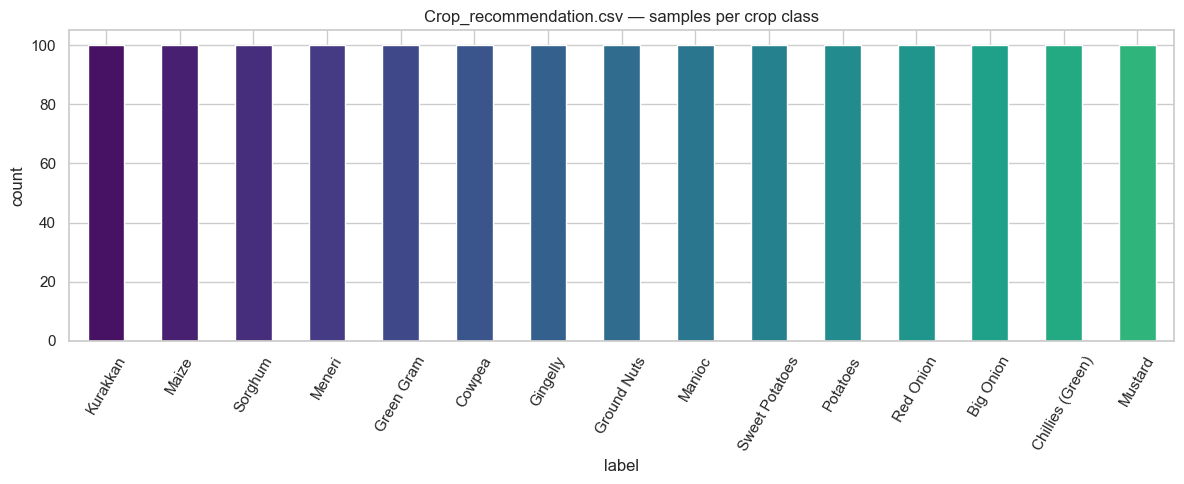

In [27]:
fig, ax = plt.subplots(figsize=(12,5))
crop_recom['label'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 22))
ax.set_title('Crop_recommendation.csv — samples per crop class')
ax.set_ylabel('count')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/01_crop_rec_class_balance.png', dpi=120)
plt.show()


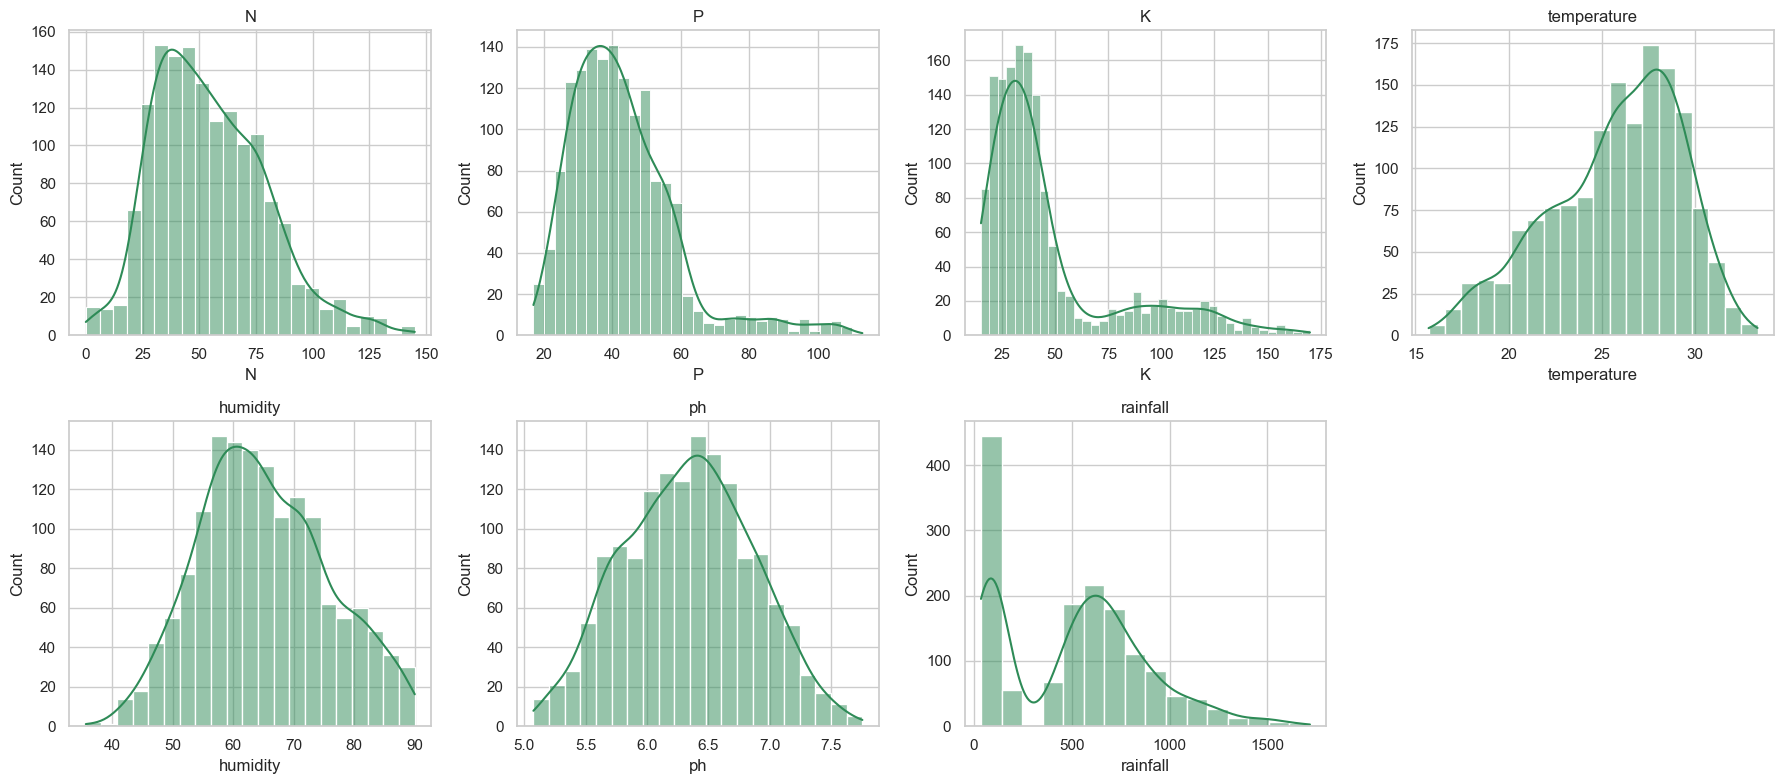

In [28]:
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(crop_recom[col], kde=True, ax=ax, color='seagreen')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/02_crop_rec_distributions.png', dpi=120)
plt.show()


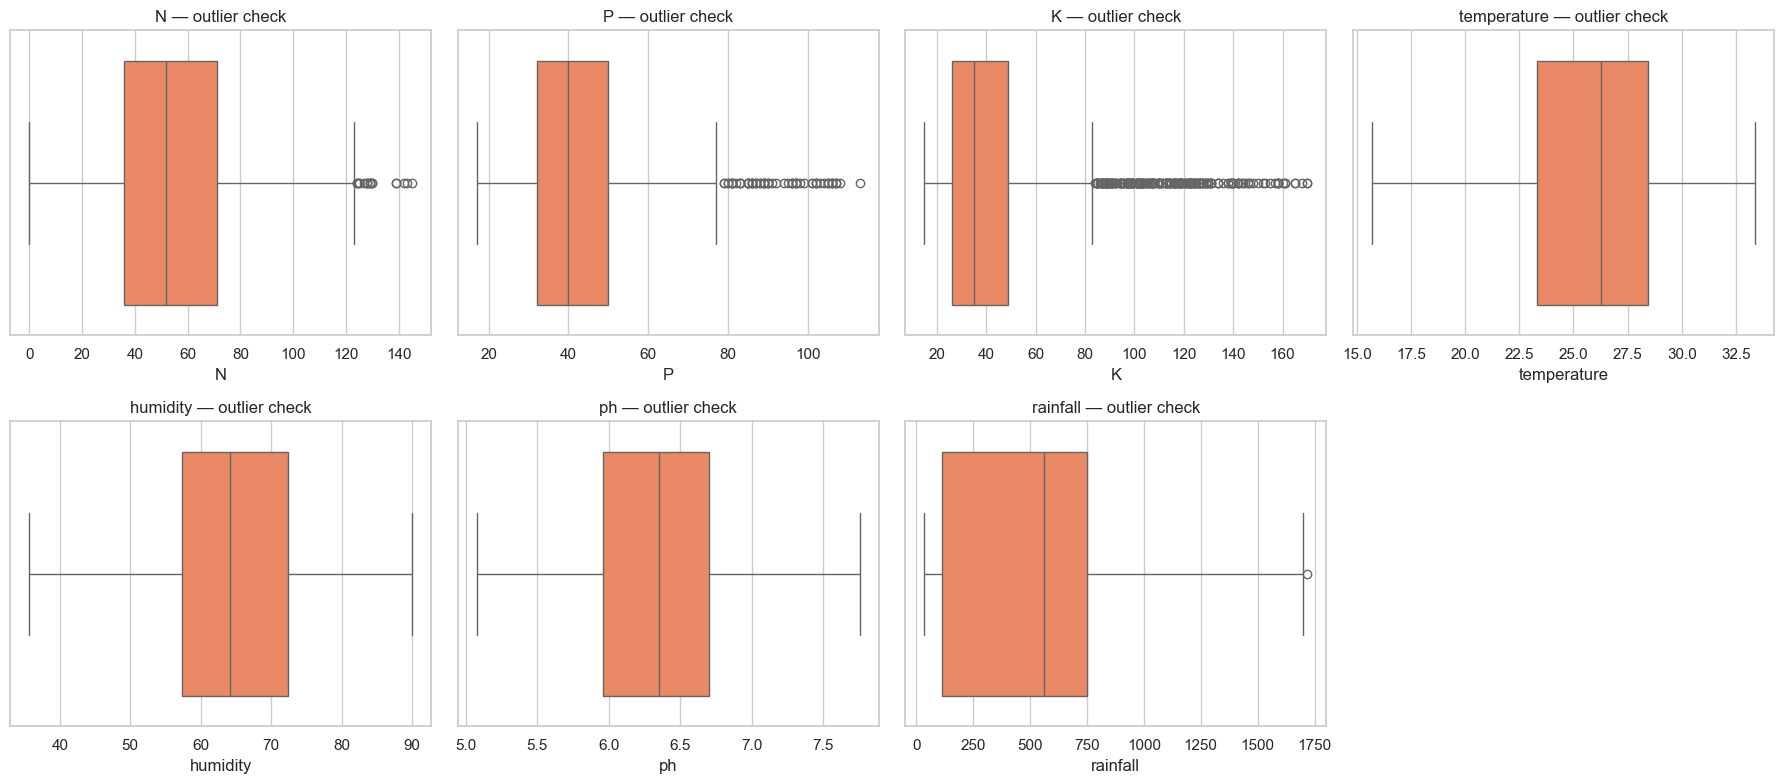

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=crop_recom[col], ax=ax, color='coral')
    ax.set_title(f'{col} — outlier check')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/03_crop_rec_boxplots.png', dpi=120)
plt.show()


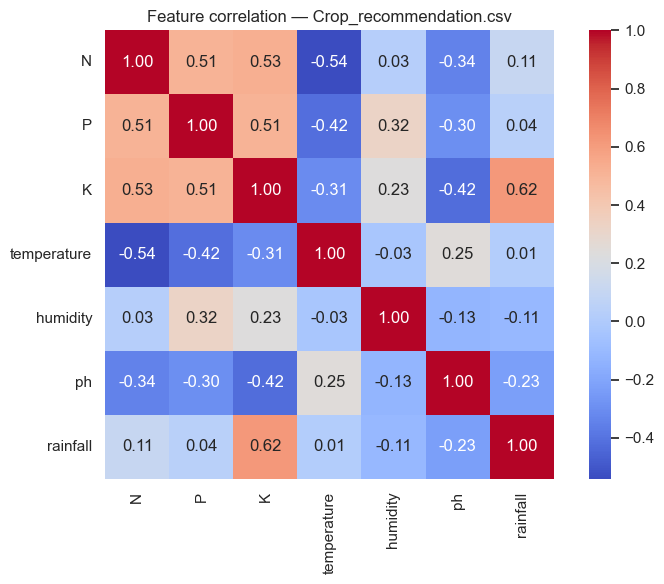

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(crop_recom[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature correlation — Crop_recommendation.csv')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/04_crop_rec_corr_heatmap.png', dpi=120)
plt.show()


### NASA POWER Weather data (2000–2025)

In [11]:
weather.info()
print('\nDate range:', weather['date'].min(), '→', weather['date'].max())
print('Districts covered:', weather['district'].nunique())
print(sorted(weather['district'].unique()))
print('\nMissing values:\n', weather.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237425 entries, 0 to 237424
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date                       237425 non-null  datetime64[ns]
 1   district                   237425 non-null  object        
 2   latitude                   237425 non-null  float64       
 3   longitude                  237425 non-null  float64       
 4   temperature_avg_c          237425 non-null  float64       
 5   temperature_max_c          237425 non-null  float64       
 6   temperature_min_c          237425 non-null  float64       
 7   rainfall_mm                237425 non-null  float64       
 8   humidity_percent           237425 non-null  float64       
 9   solar_radiation_mj_m2_day  237425 non-null  float64       
 10  wind_speed_m_s             237425 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory u

In [12]:
weather.describe().T

,count,mean,min,25%,50%,75%,max,std
date,237425,2012-12-31 00:00:00.000000256,2000-01-01 00:00:00,2006-07-02 00:00:00,2012-12-31 00:00:00,2019-07-02 00:00:00,2025-12-31 00:00:00,NaN
latitude,237425.0,7.586436,5.9549,6.9271,7.2917,8.3114,9.6615,1.034769
longitude,237425.0,80.58856,79.8283,80.2168,80.4971,81.0188,81.6747,0.53295
temperature_avg_c,237425.0,26.558,17.27,25.4,26.68,27.93,32.75,1.934465
temperature_max_c,237425.0,29.585956,21.27,28.04,29.22,30.94,41.5,2.219842
temperature_min_c,237425.0,24.319077,10.6,22.62,24.84,26.28,30.55,2.520346
rainfall_mm,237425.0,4.75241,0.0,0.19,1.48,5.8,294.22,8.639944
humidity_percent,237425.0,81.090404,48.94,76.6,81.88,86.23,97.56,6.802399
solar_radiation_mj_m2_day,237425.0,19.198766,1.04,16.99,20.05,22.34,27.63,4.283449
wind_speed_m_s,237425.0,4.636669,0.32,3.04,4.47,6.05,15.04,2.018254


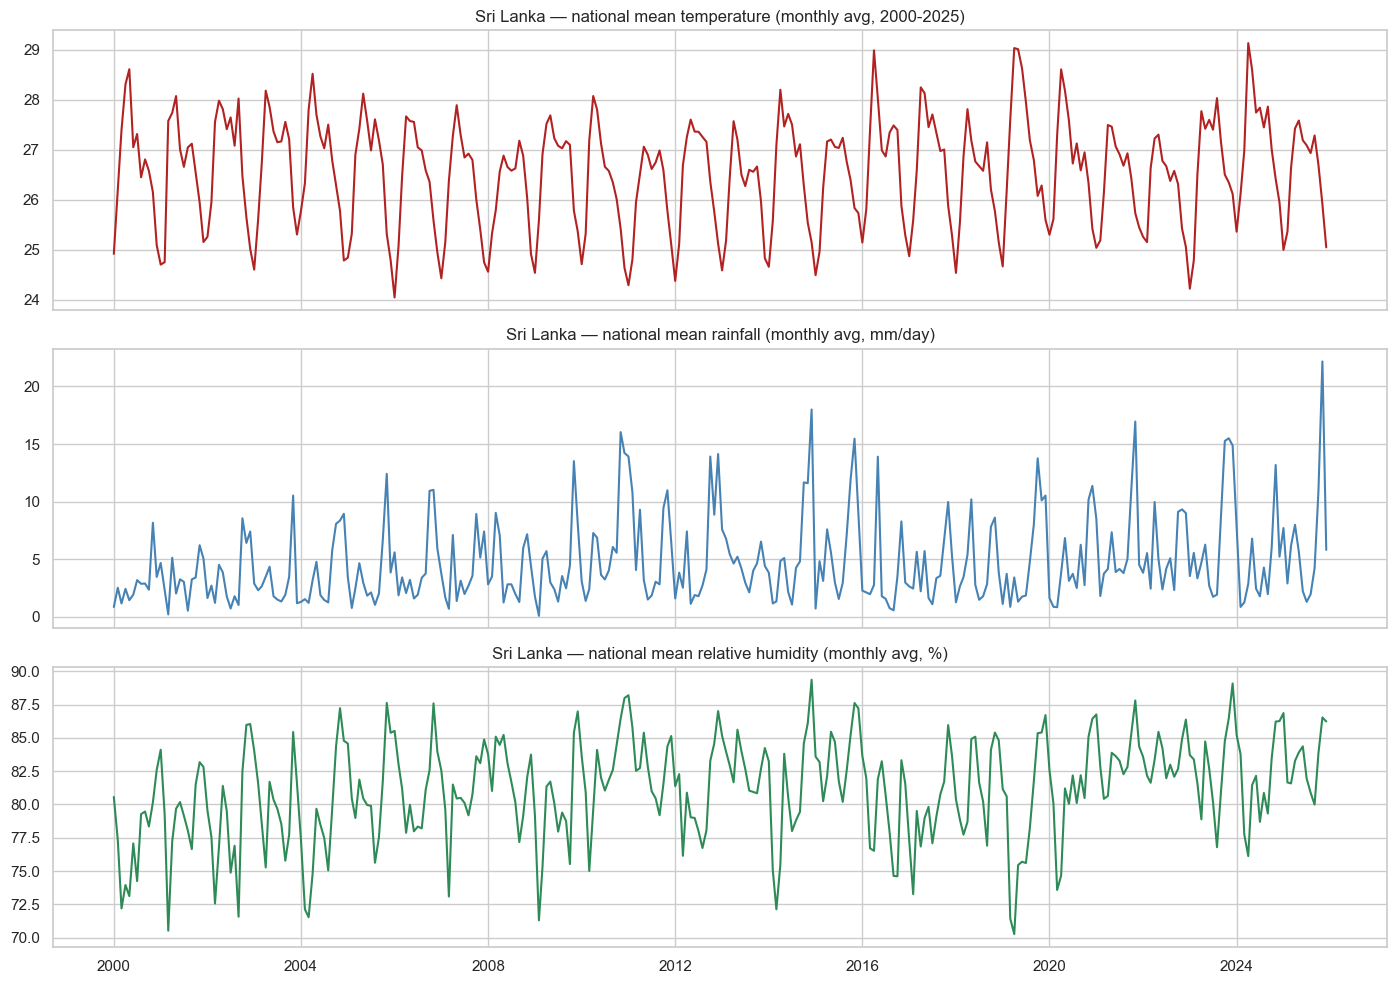

In [31]:
national_daily = weather.groupby('date')[['temperature_avg_c','rainfall_mm','humidity_percent']].mean()
national_monthly = national_daily.resample('MS').mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(national_monthly.index, national_monthly['temperature_avg_c'], color='firebrick')
axes[0].set_title('Sri Lanka — national mean temperature (monthly avg, 2000-2025)')
axes[1].plot(national_monthly.index, national_monthly['rainfall_mm'], color='steelblue')
axes[1].set_title('Sri Lanka — national mean rainfall (monthly avg, mm/day)')
axes[2].plot(national_monthly.index, national_monthly['humidity_percent'], color='seagreen')
axes[2].set_title('Sri Lanka — national mean relative humidity (monthly avg, %)')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/05_weather_national_trends.png', dpi=120)
plt.show()


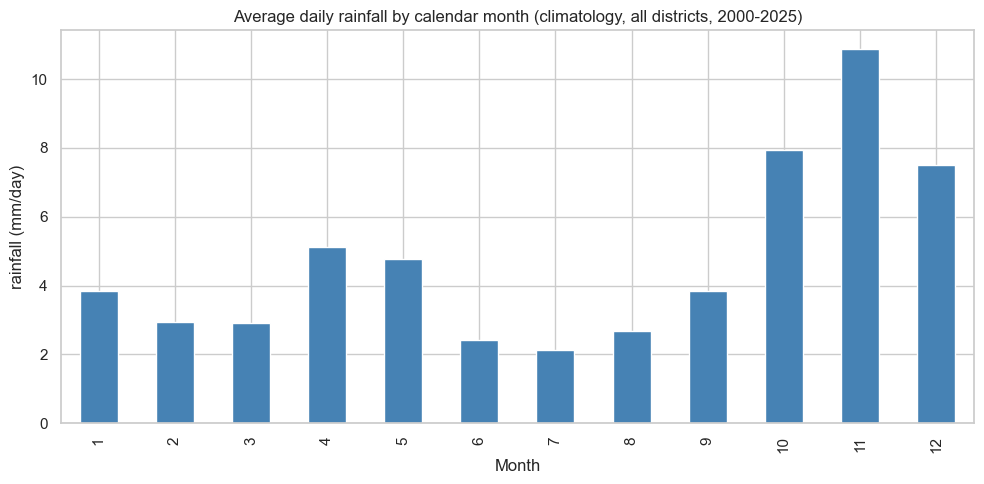

In [32]:
# Seasonality: average monthly rainfall highlights the two monsoons (Yala / Maha)
weather['month'] = weather['date'].dt.month
monthly_clim = weather.groupby('month')[['temperature_avg_c','rainfall_mm','humidity_percent']].mean()

fig, ax = plt.subplots(figsize=(10,5))
monthly_clim['rainfall_mm'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Average daily rainfall by calendar month (climatology, all districts, 2000-2025)')
ax.set_xlabel('Month'); ax.set_ylabel('rainfall (mm/day)')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/06_weather_monthly_climatology.png', dpi=120)
plt.show()


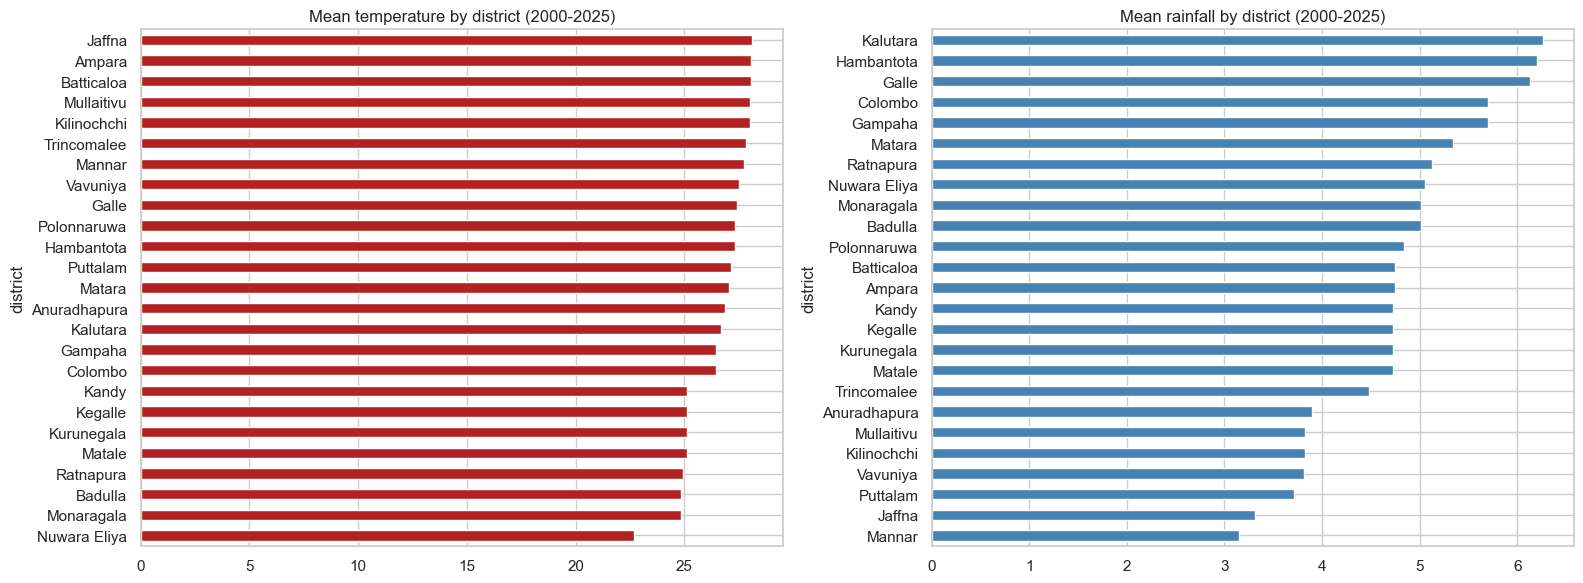

In [33]:
# District comparison — which districts are hottest / wettest on average
district_avg = weather.groupby('district')[['temperature_avg_c','rainfall_mm','humidity_percent']].mean().sort_values('temperature_avg_c')

fig, axes = plt.subplots(1, 2, figsize=(16,6))
district_avg['temperature_avg_c'].plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Mean temperature by district (2000-2025)')
district_avg.sort_values('rainfall_mm')['rainfall_mm'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Mean rainfall by district (2000-2025)')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/07_weather_district_comparison.png', dpi=120)
plt.show()


### Soil datasets

In [16]:
soil_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,5000.0,7.595063,1.022713,5.900759,6.883976,7.357112,8.287404,9.849819
Longitude,5000.0,80.590259,0.478818,79.701397,80.211135,80.593298,80.885852,81.894195
pH,5000.0,6.063328,0.801406,4.000000,5.430000,6.070000,6.690000,8.500000
Nitrogen,5000.0,1.120882,0.315683,0.278000,0.880000,1.089000,1.340000,2.202000
Phosphorus,5000.0,13.480724,4.613841,3.000000,10.297500,13.360000,16.590000,29.640000
Potassium,5000.0,135.500496,18.871811,76.550000,122.120000,134.730000,148.300000,198.040000
Organic_Carbon,5000.0,1.562066,0.672302,0.300000,1.060000,1.390000,1.950000,4.870000
Sand,5000.0,57.834302,10.710357,25.620000,49.920000,58.440000,65.890000,85.000000
Clay,5000.0,23.598680,8.478501,5.000000,17.507500,23.040000,29.690000,54.510000
Silt,5000.0,18.566880,7.249056,5.010000,13.050000,18.180000,23.580000,49.950000


In [18]:
soil_data.info()
print('\nMissing values:\n', soil_data.isnull().sum())
print('\nAgro-ecological zones:', soil_data['Agro_Ecological_Zone'].unique())
print('\nSoil orders:', soil_data['Soil_Order_Classification'].unique())
soil_data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sample_ID                  5000 non-null   object 
 1   District                   5000 non-null   object 
 2   Latitude                   5000 non-null   float64
 3   Longitude                  5000 non-null   float64
 4   Agro_Ecological_Zone       5000 non-null   object 
 5   Soil_Order_Classification  5000 non-null   object 
 6   pH                         5000 non-null   float64
 7   Nitrogen                   5000 non-null   float64
 8   Phosphorus                 5000 non-null   float64
 9   Potassium                  5000 non-null   float64
 10  Organic_Carbon             5000 non-null   float64
 11  Sand                       5000 non-null   float64
 12  Clay                       5000 non-null   float64
 13  Silt                       5000 non-null   float

,count,mean,std,min,25%,50%,75%,max
Latitude,5000.0,7.595063,1.022713,5.900759,6.883976,7.357112,8.287404,9.849819
Longitude,5000.0,80.590259,0.478818,79.701397,80.211135,80.593298,80.885852,81.894195
pH,5000.0,6.063328,0.801406,4.000000,5.430000,6.070000,6.690000,8.500000
Nitrogen,5000.0,1.120882,0.315683,0.278000,0.880000,1.089000,1.340000,2.202000
Phosphorus,5000.0,13.480724,4.613841,3.000000,10.297500,13.360000,16.590000,29.640000
Potassium,5000.0,135.500496,18.871811,76.550000,122.120000,134.730000,148.300000,198.040000
Organic_Carbon,5000.0,1.562066,0.672302,0.300000,1.060000,1.390000,1.950000,4.870000
Sand,5000.0,57.834302,10.710357,25.620000,49.920000,58.440000,65.890000,85.000000
Clay,5000.0,23.598680,8.478501,5.000000,17.507500,23.040000,29.690000,54.510000
Silt,5000.0,18.566880,7.249056,5.010000,13.050000,18.180000,23.580000,49.950000


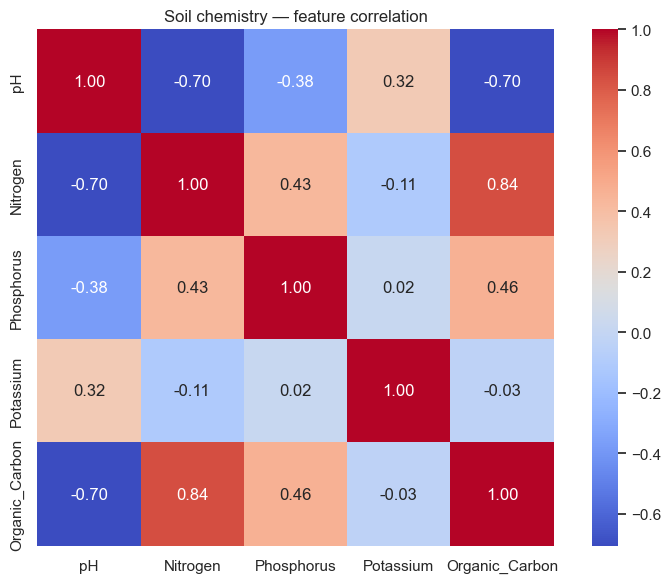

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    soil_data[
        [
            'pH',
            'Nitrogen',
            'Phosphorus',
            'Potassium',
            'Organic_Carbon'
        ]
    ].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Soil chemistry — feature correlation')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task1/08_soil_chem_corr.png', dpi=120)
plt.show()


In [20]:
soil_by_loc = soil_data.groupby('District')[
    ['pH', 'Nitrogen', 'Phosphorus', 'Potassium']
].mean().round(1)

soil_by_loc


,pH,Nitrogen,Phosphorus,Potassium
District,,,,
Ampara,6.4,1.1,14.8,145.0
Anuradhapura,6.3,0.9,11.4,124.5
Badulla,5.2,1.5,16.2,139.9
Batticaloa,6.8,1.0,13.7,149.9
Colombo,5.8,1.2,14.1,119.7
Galle,5.3,1.4,16.1,130.7
Gampaha,5.7,1.1,12.6,114.9
Hambantota,6.5,0.9,10.1,109.3
Jaffna,7.5,0.8,12.0,169.2


### Crop Supply Dataset

In [21]:
crop_supp.info()
crop_supp.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11890 entries, 0 to 11889
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   District              11890 non-null  object 
 1   Season                11890 non-null  object 
 2   Crop                  11890 non-null  object 
 3   Year                  11890 non-null  int64  
 4   Cultivated Area       11890 non-null  float64
 5   Production            11890 non-null  float64
 6   Agro_Ecological_Zone  11890 non-null  object 
 7   Spatial_Check         11890 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 743.3+ KB


,District,Season,Crop,Year,Cultivated Area,Production,Agro_Ecological_Zone,Spatial_Check
0,Ampara,Maha,Ash Plantain,2018,227.57,5647.98,Dry,Unverified
1,Ampara,Maha,Ash Plantain,2018,116.99,3320.10,Dry,Unverified
2,Ampara,Maha,Banana,2018,176.93,5122.97,Dry,Unverified
3,Ampara,Maha,Black Gram,2018,31.24,201.03,Dry,Unverified
4,Ampara,Maha,Carrot,2018,77.80,1267.06,Dry,Supported envelope


In [22]:
print('Missing values:\n')
print(crop_supp.isnull().sum())

print('\nDistricts covered:')
print(sorted(crop_supp['District'].unique()))

print('\nCrops covered:')
print(sorted(crop_supp['Crop'].unique()))

print('\nSeasons covered:')
print(sorted(crop_supp['Season'].unique()))

print('\nYears covered:')
print(sorted(crop_supp['Year'].unique()))

print('\nNumber of districts:', crop_supp['District'].nunique())
print('Number of crops:', crop_supp['Crop'].nunique())

print('\nCultivated Area summary:')
print(crop_supp['Cultivated Area'].describe())

print('\nProduction summary:')
print(crop_supp['Production'].describe())

Missing values:

District                0
Season                  0
Crop                    0
Year                    0
Cultivated Area         0
Production              0
Agro_Ecological_Zone    0
Spatial_Check           0
dtype: int64

Districts covered:
['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Monaragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']

Crops covered:
['Ash Plantain', 'Banana', 'Beans', 'Big Onion', 'Bitter Gourd', 'Black Gram', 'Brinjal', 'Cabbage', 'Carrot', 'Cassava', 'Cauliflower', 'Chilli', 'Cinnamon', 'Coconut', 'Cowpea', 'Cucumber', 'Ginger', 'Green Gram', 'Groundnut', 'Leeks', 'Long Bean', 'Maize', 'Mango', 'Okra', 'Papaya', 'Pepper', 'Pineapple', 'Potato', 'Pumpkin', 'Red Onion', 'Rice', 'Ridge Gourd', 'Sesame', 'Snake Gourd', 'Soybean', 'Sweet Potato'

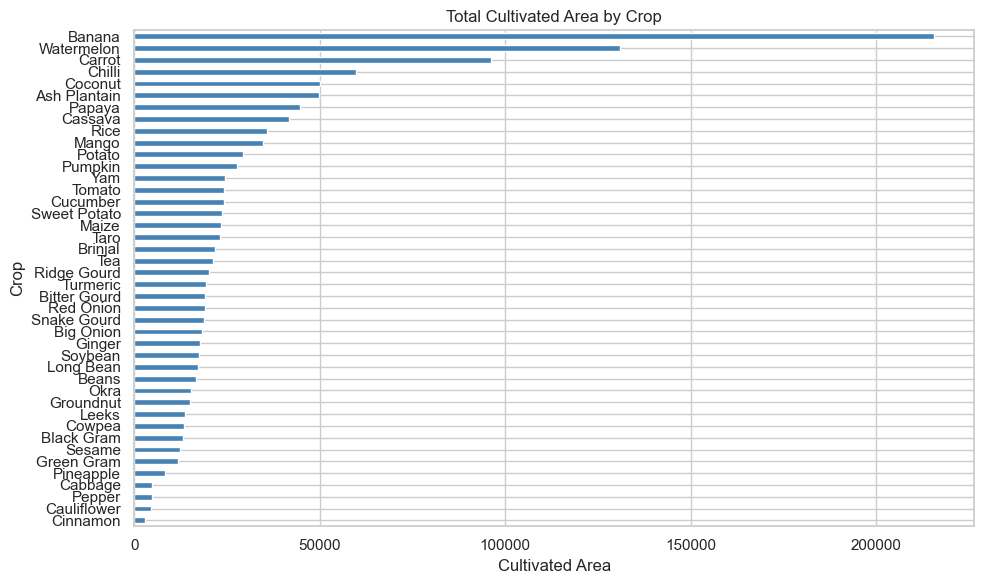

In [35]:
plt.figure(figsize=(10, 6))

crop_area = (
    crop_supp.groupby('Crop')['Cultivated Area']
    .sum()
    .sort_values()
)

crop_area.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Total Cultivated Area by Crop')
plt.xlabel('Cultivated Area')
plt.ylabel('Crop')

plt.tight_layout()
plt.savefig(
    '../outputs/notebooks_task1/09_cultivated_area_by_crop.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()


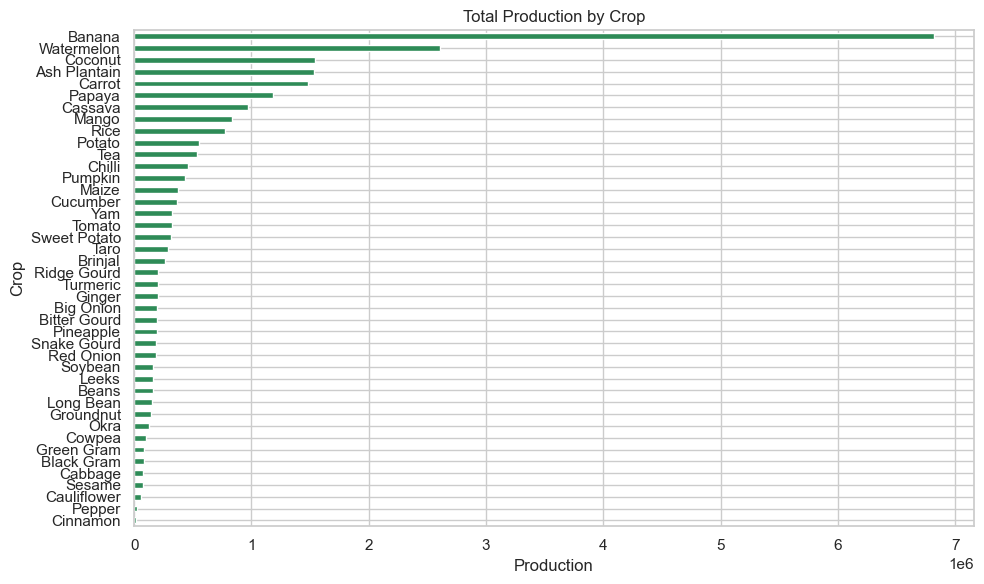

In [36]:
plt.figure(figsize=(10, 6))

crop_production = (
    crop_supp.groupby('Crop')['Production']
    .sum()
    .sort_values()
)

crop_production.plot(
    kind='barh',
    color='seagreen'
)

plt.title('Total Production by Crop')
plt.xlabel('Production')
plt.ylabel('Crop')

plt.tight_layout()
plt.savefig(
    '../outputs/notebooks_task1/10_production_by_crop.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

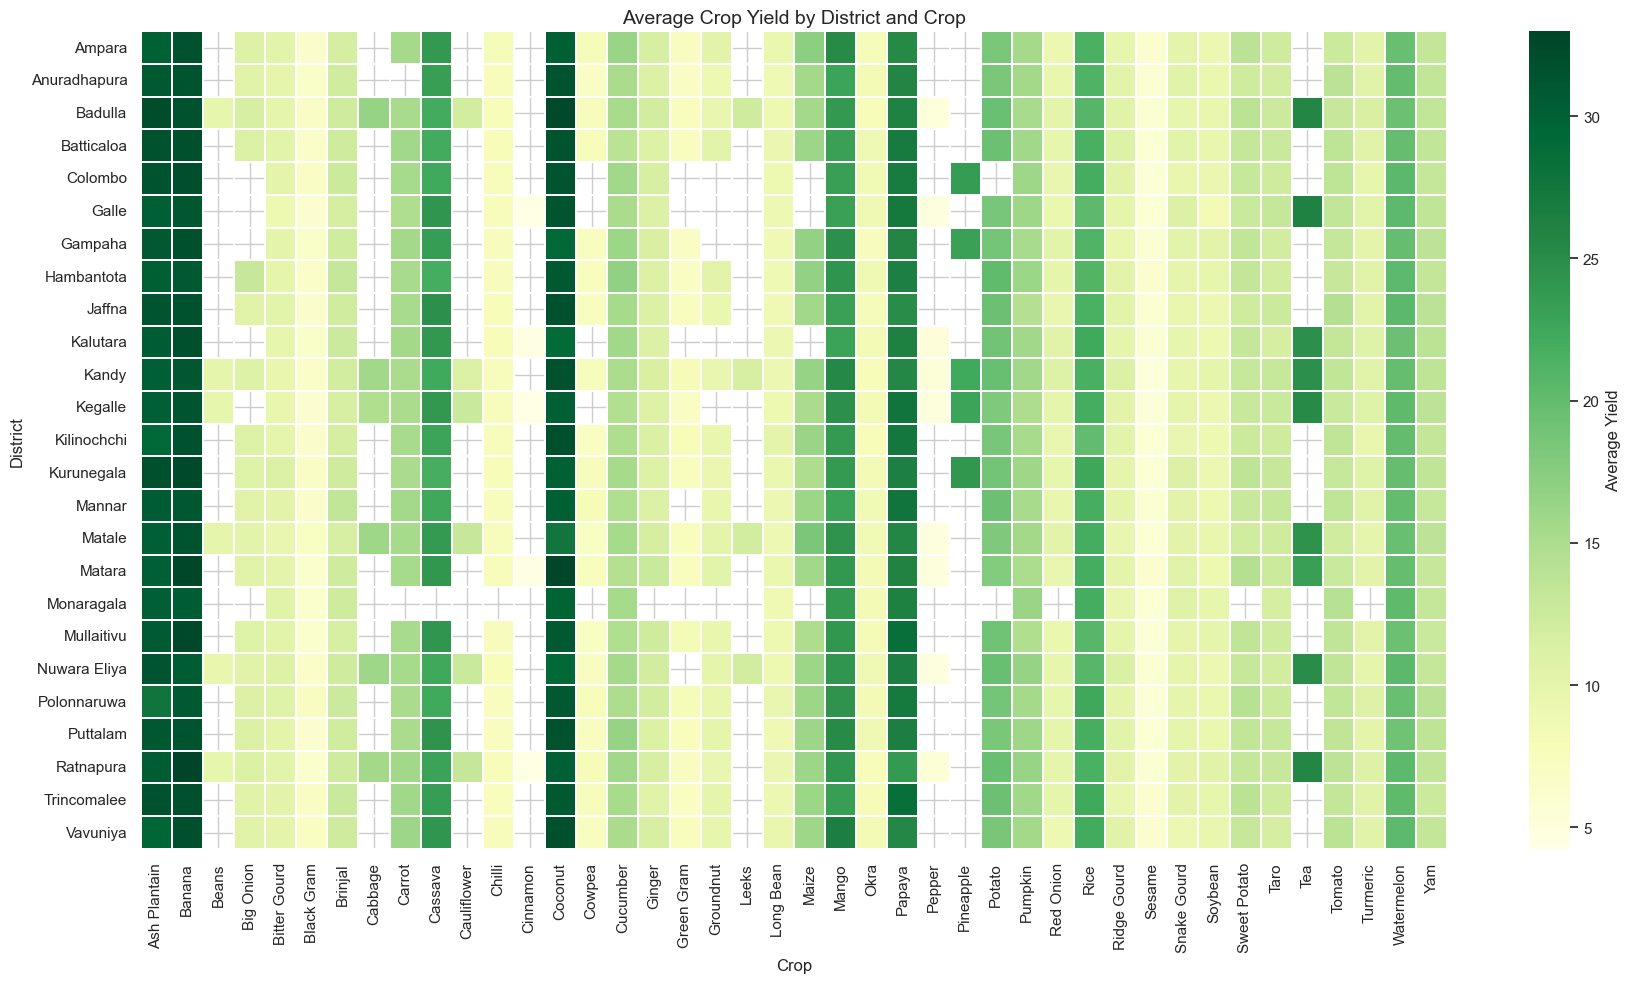

In [37]:
# Calculate yield
crop_supp['Yield'] = (
    crop_supp['Production'] / crop_supp['Cultivated Area']
)

# District × Crop average yield
pivot = crop_supp.pivot_table(
    index='District',
    columns='Crop',
    values='Yield',
    aggfunc='mean'
)

plt.figure(figsize=(18, 10))

sns.heatmap(
    pivot,
    cmap='YlGn',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Average Yield'}
)

plt.title('Average Crop Yield by District and Crop', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('District')

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    '../outputs/notebooks_task1/11_yield_heatmap_district_crop.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [38]:
print(
    f"Crop supply data covers {crop_supp['District'].nunique()} districts and "
    f"{crop_supp[['District', 'Season']].drop_duplicates().shape[0]} "
    f"district-season combinations"
)

Crop supply data covers 25 districts and 50 district-season combinations


## 6. Sri Lanka Crop Supply

In [39]:
crop_supp = pd.read_csv(f'{DATA_DIR}/sri_lanka_crop_supply_data.csv')
print("Dataset shape:", crop_supp.shape)
crop_supp.info()
crop_supp.head(10)

Dataset shape: (11890, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11890 entries, 0 to 11889
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   District              11890 non-null  object 
 1   Season                11890 non-null  object 
 2   Crop                  11890 non-null  object 
 3   Year                  11890 non-null  int64  
 4   Cultivated Area       11890 non-null  float64
 5   Production            11890 non-null  float64
 6   Agro_Ecological_Zone  11890 non-null  object 
 7   Spatial_Check         11890 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 743.3+ KB


,District,Season,Crop,Year,Cultivated Area,Production,Agro_Ecological_Zone,Spatial_Check
0,Ampara,Maha,Ash Plantain,2018,227.57,5647.98,Dry,Unverified
1,Ampara,Maha,Ash Plantain,2018,116.99,3320.10,Dry,Unverified
2,Ampara,Maha,Banana,2018,176.93,5122.97,Dry,Unverified
3,Ampara,Maha,Black Gram,2018,31.24,201.03,Dry,Unverified
4,Ampara,Maha,Carrot,2018,77.80,1267.06,Dry,Supported envelope
5,Ampara,Maha,Carrot,2018,66.16,808.93,Dry,Supported envelope
6,Ampara,Maha,Cassava,2018,118.85,2657.79,Dry,Supported envelope
7,Ampara,Maha,Chilli,2018,53.98,399.64,Dry,Supported envelope
8,Ampara,Maha,Chilli,2018,61.09,466.10,Dry,Supported envelope
9,Ampara,Maha,Chilli,2018,50.75,546.06,Dry,Supported envelope


In [40]:
print('Missing values:\n')
print(crop_supp.isnull().sum())

print('\nDuplicate rows:')
print(crop_supp.duplicated().sum())

print(
    '\nDistricts covered:',
    sorted(crop_supp['District'].unique()),
    f"({crop_supp['District'].nunique()} districts)"
)

print('\nCrops covered:')
print(sorted(crop_supp['Crop'].unique()))

print('\nSeasons covered:')
print(sorted(crop_supp['Season'].unique()))

print('\nYears covered:')
print(sorted(crop_supp['Year'].unique()))

print('\nCultivated Area summary:')
print(crop_supp['Cultivated Area'].describe())

print('\nProduction summary:')
print(crop_supp['Production'].describe())

Missing values:

District                0
Season                  0
Crop                    0
Year                    0
Cultivated Area         0
Production              0
Agro_Ecological_Zone    0
Spatial_Check           0
dtype: int64

Duplicate rows:
0

Districts covered: ['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Monaragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya'] (25 districts)

Crops covered:
['Ash Plantain', 'Banana', 'Beans', 'Big Onion', 'Bitter Gourd', 'Black Gram', 'Brinjal', 'Cabbage', 'Carrot', 'Cassava', 'Cauliflower', 'Chilli', 'Cinnamon', 'Coconut', 'Cowpea', 'Cucumber', 'Ginger', 'Green Gram', 'Groundnut', 'Leeks', 'Long Bean', 'Maize', 'Mango', 'Okra', 'Papaya', 'Pepper', 'Pineapple', 'Potato', 'Pumpkin', 'Red Onion', 'Rice', 'Ridge Gourd', 'Sesame', 'Snake

In [41]:
expected = (
    crop_supp['District'].nunique()
    * crop_supp['Crop'].nunique()
    * crop_supp['Season'].nunique()
)

actual = crop_supp[
    ['District', 'Crop', 'Season']
].drop_duplicates().shape[0]

print(
    f'Combinations present: {actual} / {expected} possible '
    f'District × Crop × Season combinations'
)

Combinations present: 1715 / 2100 possible District × Crop × Season combinations


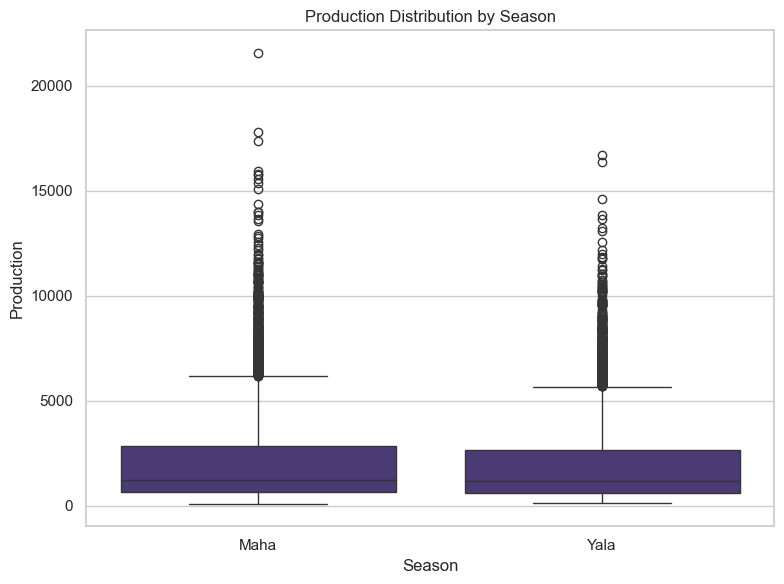

In [42]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=crop_supp,
    x='Season',
    y='Production'
)

plt.title('Production Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Production')

plt.tight_layout()

plt.savefig(
    '../outputs/notebooks_task1/12_production_by_season.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

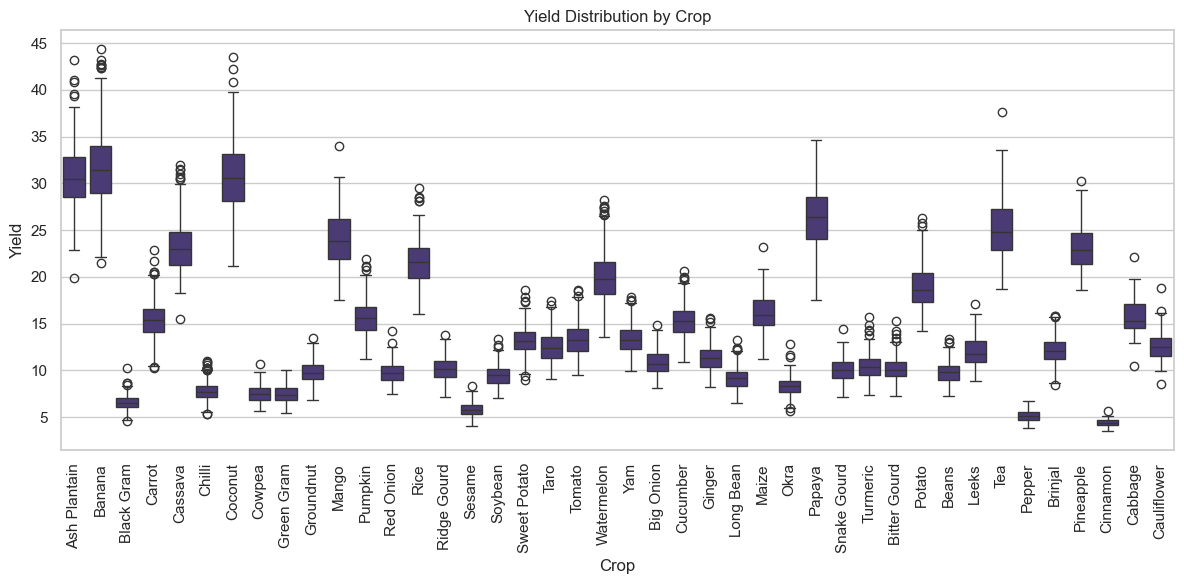

In [43]:
crop_supp['Yield'] = (
    crop_supp['Production'] / crop_supp['Cultivated Area']
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=crop_supp,
    x='Crop',
    y='Yield'
)

plt.title('Yield Distribution by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield')

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    '../outputs/notebooks_task1/13_yield_by_crop.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()